# Sentiment Analysis Pipeline
## FYE Town Hall Meeting Survey Analysis

**Author:** Student Researcher  
**Project:** First Year Experience Research and Engagement  
**Institution:** California State University, Chico  
**Date:** April 2026

---

## Notebook Overview

This notebook applies sentiment analysis to preprocessed THM survey responses using VADER (Valence Aware Dictionary and sEntiment Reasoner).

### Objectives:
1. Load preprocessed sentence-level data from Google Drive
2. Apply VADER sentiment scoring to each sentence
3. Aggregate sentiment at response level
4. Analyze trends by Semester × Question_Category
5. Generate visualizations and save outputs to Google Drive

### Why VADER?
- Optimized for social media and informal text (similar to survey responses)
- Handles negations, intensifiers, and punctuation-based emphasis
- Fast and interpretable (no training required)
- Provides granular scores: positive, negative, neutral, and compound

---
## 1. Environment Setup

In [1]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from tqdm.auto import tqdm
tqdm.pandas()

# Project imports
sys.path.append('..')
from utils.gdrive_auth import DriveDataLoader
from config import PREPROCESSED_DATA_FOLDER_ID, MAIN_FOLDER_ID, GDRIVE_FILES

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✓ Imports successful")

✓ Imports successful


### Download VADER Lexicon

In [2]:
print("Downloading VADER lexicon...")
nltk.download('vader_lexicon', quiet=True)

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Quick test
test_sentences = [
    "The event was extremely helpful and informative!",
    "I did not find this useful at all.",
    "It was okay, nothing special."
]

print("\nVADER Test:")
for sent in test_sentences:
    scores = sia.polarity_scores(sent)
    print(f"  '{sent[:40]}...' → compound: {scores['compound']:.3f}")

print("\n✓ VADER ready")


VADER Test:
  'The event was extremely helpful and info...' → compound: 0.524
  'I did not find this useful at all....' → compound: 0.523
  'It was okay, nothing special....' → compound: -0.092

✓ VADER ready


---
## 2. Load Preprocessed Data from Google Drive

In [3]:
print("Initializing Google Drive connection...")
loader = DriveDataLoader()

# Run access check
all_ok = loader.run_full_check(
    main_folder_id   = MAIN_FOLDER_ID,
    output_folder_id = PREPROCESSED_DATA_FOLDER_ID,
    gdrive_files = GDRIVE_FILES
)

if not all_ok:
    raise SystemExit('\n⛔ Access check failed. Fix the issues above before proceeding.')

Initializing Google Drive connection...

  FYE PROJECT — GOOGLE DRIVE ACCESS CHECK

GOOGLE DRIVE AUTHENTICATION

🔐 You will be prompted to log in with your Google account
📋 Make sure you have access to the THM_Survey_Data folder

Steps:
  1. Browser will open
  2. Select your Google account
  3. Click 'Allow' to grant access
  4. Return here to continue


→ Refreshing expired token...

✓ AUTHENTICATED AS: hvhasabnis@csuchico.edu

✓ Ready to load data from Google Drive

  🔍 Checking READ access... ✅  (2 files visible)
  🔍 Checking WRITE access... ✅

  🔍 Verifying all dataset files...
    ✅  text_prepared        — THM_All_Semesters_TEXT_PREPARED (315 KB)
    ✅  quant_prepared       — THM_All_Semesters_QUANTITATIVE_PREPARED (17 KB)
    ✅  fall_2022            — THM_Fall_2022 (60 KB)
    ✅  spring_2023          — THM_Spring_2023 (63 KB)
    ✅  fall_2023            — THM_Fall_2023 (33 KB)
    ✅  spring_2024          — THM_Spring_2024 (23 KB)
    ✅  fall_2024            — THM_Fall_2024 (61 K

In [4]:
print("Loading preprocessed sentences from Drive...")

# Find the preprocessed_sentences.csv file in the preprocessed folder
file_list = loader.drive.ListFile({
    'q': f"'{PREPROCESSED_DATA_FOLDER_ID}' in parents and trashed=false and title='preprocessed_sentences.csv'"
}).GetList()

if not file_list:
    raise FileNotFoundError("preprocessed_sentences.csv not found in Drive. Run 02_text_preprocessing first.")

file_id = file_list[0]['id']
df_sentences = loader.read_csv(file_id, label='preprocessed_sentences')

print(f"\nDataset loaded successfully!")
print(f"  Total sentences: {len(df_sentences):,}")
print(f"  Columns: {list(df_sentences.columns)}")
print(f"  Semesters: {df_sentences['Semester'].nunique()}")

Loading preprocessed sentences from Drive...
  [preprocessed_sentences] Loading CSV (ID: 1PO_tJniIdHCoswzTlft...)... ✓ (14836, 3)

Dataset loaded successfully!
  Total sentences: 14,836
  Columns: ['Semester', 'Question_Category', 'sentence']
  Semesters: 7


In [5]:
# Preview data
print("\nSample sentences:")
for idx, row in df_sentences.sample(5, random_state=42).iterrows():
    print(f"  [{row['Semester']}] {row['sentence'][:80]}...")


Sample sentences:
  [Fall_2022] | when enrolling into classes i had upperclassmen telling me this is a good cour...
  [Spring_2023] | nothing, everything went smoothly in my opinion....
  [Fall_2025] describe how or why you do or do not feel an increased confidence in your academ...
  [Fall_2025] | creating change: responses to this question help us accurately describe any in...
  [Fall_2024] fall_2024_2 | fall | food, agriculture, and animal policy | describe your experi...


---
## 3. Sentence-Level Sentiment Analysis

In [6]:
def get_vader_scores(text):
    """
    Apply VADER sentiment analysis to a text string.
    
    Returns:
        dict with 'neg', 'neu', 'pos', 'compound' scores
    """
    if not isinstance(text, str) or not text.strip():
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
    return sia.polarity_scores(text)


def classify_sentiment(compound_score):
    """
    Classify sentiment based on compound score.
    
    Thresholds (standard VADER recommendations):
        compound >= 0.05  → Positive
        compound <= -0.05 → Negative
        else              → Neutral
    """
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'


print("Function test:")
test = "The professors are very helpful and supportive!"
scores = get_vader_scores(test)
print(f"  Text: '{test}'")
print(f"  Scores: {scores}")
print(f"  Label: {classify_sentiment(scores['compound'])}")

Function test:
  Text: 'The professors are very helpful and supportive!'
  Scores: {'neg': 0.0, 'neu': 0.461, 'pos': 0.539, 'compound': 0.7049}
  Label: Positive


In [7]:
print("Applying VADER to all sentences...\n")

# Apply VADER
vader_results = df_sentences['sentence'].progress_apply(get_vader_scores)

# Extract individual scores
df_sentences['vader_neg'] = vader_results.apply(lambda x: x['neg'])
df_sentences['vader_neu'] = vader_results.apply(lambda x: x['neu'])
df_sentences['vader_pos'] = vader_results.apply(lambda x: x['pos'])
df_sentences['vader_compound'] = vader_results.apply(lambda x: x['compound'])

# Classify sentiment
df_sentences['sentiment_label'] = df_sentences['vader_compound'].apply(classify_sentiment)

print("\n✓ Sentiment analysis complete!")

Applying VADER to all sentences...



100%|██████████| 14836/14836 [00:04<00:00, 3354.25it/s]


✓ Sentiment analysis complete!


In [8]:
print("\nSENTIMENT DISTRIBUTION (Sentence-Level)")
print("=" * 50)

sentiment_counts = df_sentences['sentiment_label'].value_counts()
sentiment_pcts = df_sentences['sentiment_label'].value_counts(normalize=True) * 100

for label in ['Positive', 'Neutral', 'Negative']:
    count = sentiment_counts.get(label, 0)
    pct = sentiment_pcts.get(label, 0)
    print(f"  {label:10s}: {count:6,} ({pct:5.1f}%)")

print(f"\nCompound Score Statistics:")
print(f"  Mean:   {df_sentences['vader_compound'].mean():.3f}")
print(f"  Median: {df_sentences['vader_compound'].median():.3f}")
print(f"  Std:    {df_sentences['vader_compound'].std():.3f}")


SENTIMENT DISTRIBUTION (Sentence-Level)
  Positive  :  9,948 ( 67.1%)
  Neutral   :  4,131 ( 27.8%)
  Negative  :    757 (  5.1%)

Compound Score Statistics:
  Mean:   0.392
  Median: 0.440
  Std:    0.365


---
## 4. Response-Level Aggregation

Since multiple sentences come from each original survey response, we aggregate to get response-level sentiment.

In [9]:
# Load preprocessed_full.csv to get Response IDs for proper aggregation
print("Loading full preprocessed data for response-level aggregation...")

file_list = loader.drive.ListFile({
    'q': f"'{PREPROCESSED_DATA_FOLDER_ID}' in parents and trashed=false and title='preprocessed_full.csv'"
}).GetList()

if file_list:
    file_id = file_list[0]['id']
    df_full = loader.read_csv(file_id, label='preprocessed_full')
    print(f"  Loaded {len(df_full):,} responses")
else:
    print("  ⚠ preprocessed_full.csv not found - using sentence grouping")
    df_full = None

Loading full preprocessed data for response-level aggregation...
  [preprocessed_full] Loading CSV (ID: 1fY534qmzYtRIz7Gp6HX...)... ✓ (3585, 8)
  Loaded 3,585 responses


In [10]:
# Since sentences were exploded from responses, we need to group back
# The original index from explode becomes implicit grouping

# Add a response_id based on original row position (sentences share same Semester + Question_Category + implicit order)
# For now, group by Semester + Question_Category as response proxy

print("Aggregating sentiment to response level...")

# Create response groups using cumcount to identify unique responses
# This assumes sentences for the same response are consecutive
df_sentences['response_group'] = (
    (df_sentences['Semester'] != df_sentences['Semester'].shift()) | 
    (df_sentences['Question_Category'] != df_sentences['Question_Category'].shift())
).cumsum()

# Aggregate by response
df_responses = df_sentences.groupby(['response_group', 'Semester', 'Question_Category']).agg({
    'vader_compound': ['mean', 'min', 'max', 'std'],
    'vader_pos': 'mean',
    'vader_neg': 'mean',
    'vader_neu': 'mean',
    'sentence': 'count'
}).reset_index()

# Flatten column names
df_responses.columns = [
    'response_group', 'Semester', 'Question_Category',
    'compound_mean', 'compound_min', 'compound_max', 'compound_std',
    'pos_mean', 'neg_mean', 'neu_mean', 'sentence_count'
]

# Fill NaN std (single-sentence responses)
df_responses['compound_std'] = df_responses['compound_std'].fillna(0)

# Classify response-level sentiment
df_responses['sentiment_label'] = df_responses['compound_mean'].apply(classify_sentiment)

print(f"\n✓ Aggregated to {len(df_responses):,} responses")

Aggregating sentiment to response level...

✓ Aggregated to 27 responses


In [11]:
print("\nSENTIMENT DISTRIBUTION (Response-Level)")
print("=" * 50)

response_sentiment = df_responses['sentiment_label'].value_counts()
response_pcts = df_responses['sentiment_label'].value_counts(normalize=True) * 100

for label in ['Positive', 'Neutral', 'Negative']:
    count = response_sentiment.get(label, 0)
    pct = response_pcts.get(label, 0)
    print(f"  {label:10s}: {count:6,} ({pct:5.1f}%)")

print(f"\nAverage sentences per response: {df_responses['sentence_count'].mean():.1f}")


SENTIMENT DISTRIBUTION (Response-Level)
  Positive  :     21 ( 77.8%)
  Neutral   :      5 ( 18.5%)
  Negative  :      1 (  3.7%)

Average sentences per response: 549.5


---
## 5. Semester × Category Analysis

In [12]:
print("\nSENTIMENT BY SEMESTER")
print("=" * 60)

semester_stats = df_responses.groupby('Semester').agg({
    'compound_mean': ['mean', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'Positive').mean() * 100
}).round(3)

semester_stats.columns = ['Mean Compound', 'Std', 'Responses', '% Positive']
semester_stats = semester_stats.sort_index()

print(semester_stats.to_string())


SENTIMENT BY SEMESTER
             Mean Compound    Std  Responses  % Positive
Semester                                                
Fall_2022            0.277  0.161          3     100.000
Fall_2023            0.143  0.207          4      50.000
Fall_2024            0.183  0.247          3      33.333
Fall_2025            0.458  0.261          4     100.000
Spring_2023          0.266  0.178          3     100.000
Spring_2024          0.315  0.195          6     100.000
Spring_2025          0.220  0.242          4      50.000


In [13]:
print("\nSENTIMENT BY QUESTION CATEGORY")
print("=" * 60)

category_stats = df_responses.groupby('Question_Category').agg({
    'compound_mean': ['mean', 'std', 'count'],
    'sentiment_label': lambda x: (x == 'Positive').mean() * 100
}).round(3)

category_stats.columns = ['Mean Compound', 'Std', 'Responses', '% Positive']
category_stats = category_stats.sort_values('Mean Compound', ascending=False)

print(category_stats.to_string())


SENTIMENT BY QUESTION CATEGORY
                         Mean Compound    Std  Responses  % Positive
Question_Category                                                   
Confidence                       0.735    NaN          1     100.000
Learning_Civic                   0.514    NaN          1     100.000
Suggestions_Improvement          0.465  0.005          2     100.000
Community_Connection             0.439    NaN          1     100.000
Casual_Description               0.433  0.031          3     100.000
Other                            0.386  0.147          5     100.000
Personal_Meaning                 0.277  0.136          3     100.000
Motivation                       0.137  0.028          3     100.000
Learning_Action                  0.058  0.038          3      33.333
Learning_General                 0.022    NaN          1       0.000
Learning_Breakout                0.016  0.088          4      25.000


In [14]:
# Create Semester × Category pivot table
print("\nSEMESTER × CATEGORY PIVOT (Mean Compound Score)")
print("=" * 60)

pivot = df_responses.pivot_table(
    values='compound_mean',
    index='Question_Category',
    columns='Semester',
    aggfunc='mean'
).round(3)

print(pivot.to_string())


SEMESTER × CATEGORY PIVOT (Mean Compound Score)
Semester                 Fall_2022  Fall_2023  Fall_2024  Fall_2025  Spring_2023  Spring_2024  Spring_2025
Question_Category                                                                                         
Casual_Description             NaN        NaN      0.467        NaN          NaN        0.406        0.425
Community_Connection           NaN        NaN        NaN      0.439          NaN          NaN          NaN
Confidence                     NaN        NaN        NaN      0.735          NaN          NaN          NaN
Learning_Action                NaN      0.034      0.039        NaN          NaN        0.102          NaN
Learning_Breakout              NaN     -0.093      0.041        NaN          NaN        0.117       -0.000
Learning_Civic                 NaN        NaN        NaN        NaN          NaN        0.514          NaN
Learning_General               NaN        NaN        NaN        NaN          NaN          NaN  

---
## 6. Visualizations

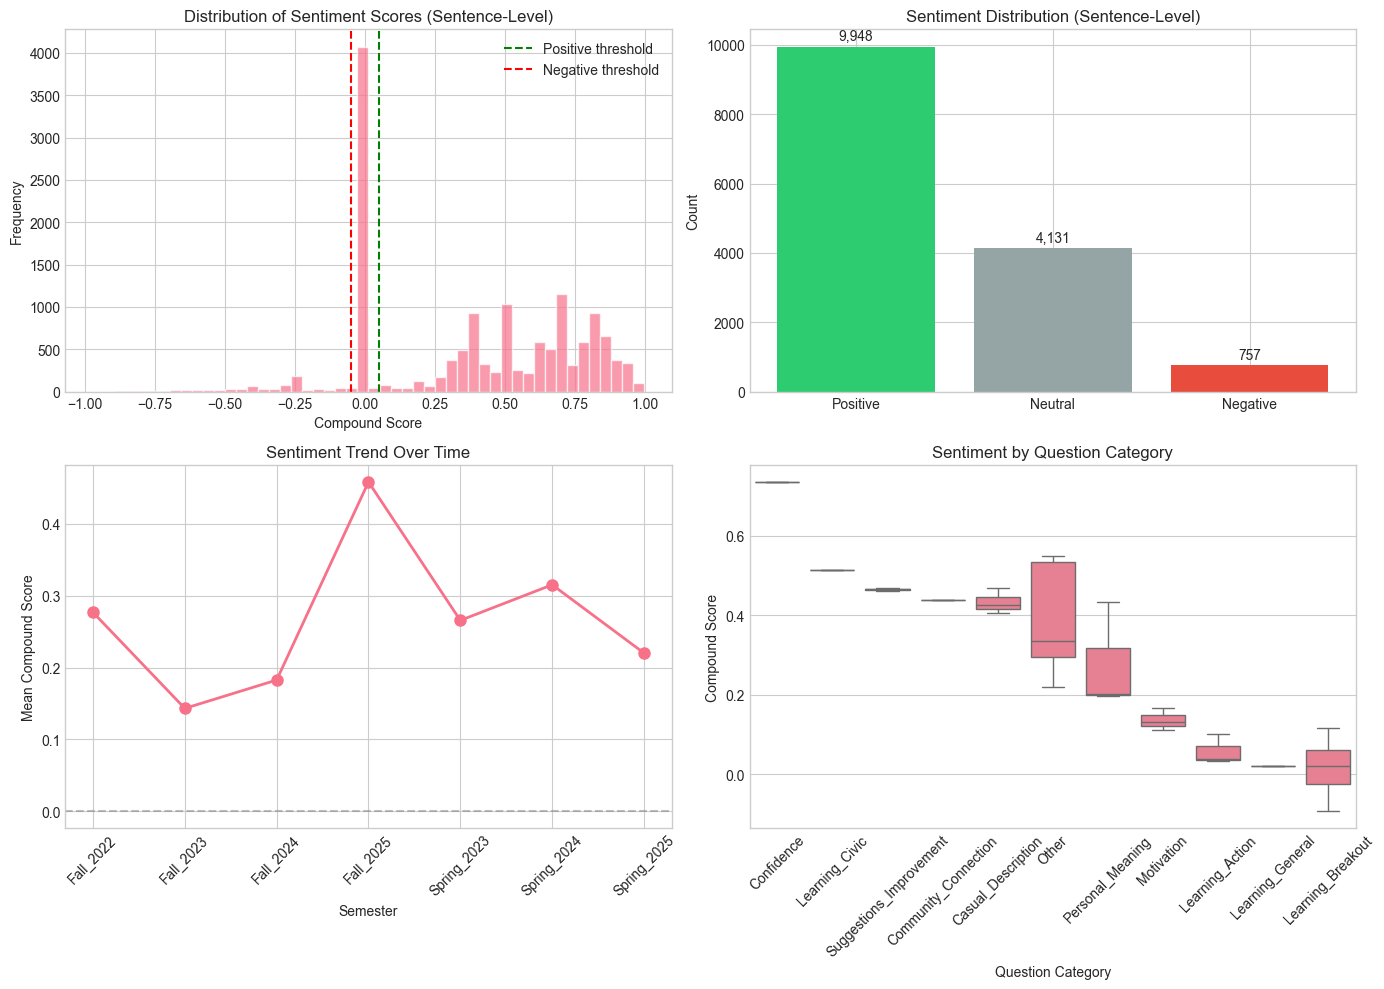


✓ Visualization saved


In [15]:
# Create output directory for plots
output_dir = Path('../outputs/02_sentiment')
output_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Compound score distribution
ax1 = axes[0, 0]
ax1.hist(df_sentences['vader_compound'], bins=50, edgecolor='white', alpha=0.7)
ax1.axvline(x=0.05, color='green', linestyle='--', label='Positive threshold')
ax1.axvline(x=-0.05, color='red', linestyle='--', label='Negative threshold')
ax1.set_xlabel('Compound Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Sentiment Scores (Sentence-Level)')
ax1.legend()

# 2. Sentiment label distribution
ax2 = axes[0, 1]
colors = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}
sentiment_counts = df_sentences['sentiment_label'].value_counts()
bars = ax2.bar(sentiment_counts.index, sentiment_counts.values, 
               color=[colors[x] for x in sentiment_counts.index])
ax2.set_ylabel('Count')
ax2.set_title('Sentiment Distribution (Sentence-Level)')
for bar, count in zip(bars, sentiment_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, 
             f'{count:,}', ha='center', va='bottom', fontsize=10)

# 3. Sentiment trend by semester
ax3 = axes[1, 0]
semester_order = sorted(df_responses['Semester'].unique())
semester_means = df_responses.groupby('Semester')['compound_mean'].mean().reindex(semester_order)
ax3.plot(semester_order, semester_means.values, marker='o', linewidth=2, markersize=8)
ax3.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax3.set_xlabel('Semester')
ax3.set_ylabel('Mean Compound Score')
ax3.set_title('Sentiment Trend Over Time')
ax3.tick_params(axis='x', rotation=45)

# 4. Sentiment by Question Category (box plot)
ax4 = axes[1, 1]
category_order = df_responses.groupby('Question_Category')['compound_mean'].mean().sort_values(ascending=False).index
df_responses['Question_Category'] = pd.Categorical(df_responses['Question_Category'], categories=category_order, ordered=True)
sns.boxplot(data=df_responses, x='Question_Category', y='compound_mean', ax=ax4)
ax4.set_xlabel('Question Category')
ax4.set_ylabel('Compound Score')
ax4.set_title('Sentiment by Question Category')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(output_dir / 'sentiment_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved")

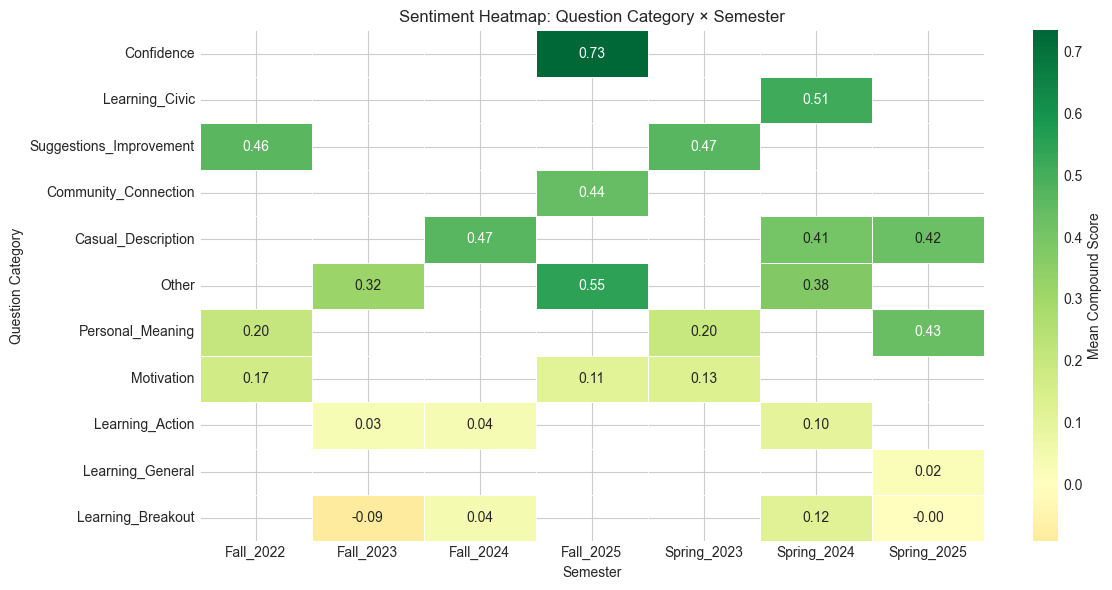

✓ Heatmap saved


In [16]:
# Heatmap: Semester × Category
plt.figure(figsize=(12, 6))

heatmap_data = df_responses.pivot_table(
    values='compound_mean',
    index='Question_Category',
    columns='Semester',
    aggfunc='mean'
)

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, cbar_kws={'label': 'Mean Compound Score'})

plt.title('Sentiment Heatmap: Question Category × Semester')
plt.xlabel('Semester')
plt.ylabel('Question Category')
plt.tight_layout()
plt.savefig(output_dir / 'sentiment_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Heatmap saved")

---
## 7. Save Outputs

In [17]:
# Prepare output DataFrames
print("Preparing output files...\n")

# 1. Sentence-level sentiment
df_sent_output = df_sentences[[
    'Semester', 'Question_Category', 'sentence',
    'vader_compound', 'vader_pos', 'vader_neu', 'vader_neg', 'sentiment_label'
]].copy()

# 2. Response-level sentiment
df_resp_output = df_responses[[
    'Semester', 'Question_Category', 'sentence_count',
    'compound_mean', 'compound_min', 'compound_max', 'compound_std',
    'pos_mean', 'neg_mean', 'neu_mean', 'sentiment_label'
]].copy()

# 3. Aggregated by Semester × Category
df_agg_output = df_responses.groupby(['Semester', 'Question_Category']).agg({
    'compound_mean': ['mean', 'std', 'count'],
    'sentiment_label': [
        lambda x: (x == 'Positive').sum(),
        lambda x: (x == 'Neutral').sum(),
        lambda x: (x == 'Negative').sum()
    ]
}).reset_index()

df_agg_output.columns = [
    'Semester', 'Question_Category',
    'mean_compound', 'std_compound', 'response_count',
    'positive_count', 'neutral_count', 'negative_count'
]

# Calculate percentages
df_agg_output['pct_positive'] = (df_agg_output['positive_count'] / df_agg_output['response_count'] * 100).round(1)
df_agg_output['pct_negative'] = (df_agg_output['negative_count'] / df_agg_output['response_count'] * 100).round(1)

print(f"Output files prepared:")
print(f"  sentiment_sentences.csv: {len(df_sent_output):,} rows")
print(f"  sentiment_responses.csv: {len(df_resp_output):,} rows")
print(f"  sentiment_by_semester_category.csv: {len(df_agg_output):,} rows")

Preparing output files...

Output files prepared:
  sentiment_sentences.csv: 14,836 rows
  sentiment_responses.csv: 27 rows
  sentiment_by_semester_category.csv: 77 rows


In [18]:
# Save locally
df_sent_output.to_csv(output_dir / 'sentiment_sentences.csv', index=False)
df_resp_output.to_csv(output_dir / 'sentiment_responses.csv', index=False)
df_agg_output.to_csv(output_dir / 'sentiment_by_semester_category.csv', index=False)

print("✓ Files saved locally")

✓ Files saved locally


In [19]:
print("\nUploading to Google Drive...\n")

if loader._write_ok:
    files = [
        ('sentiment_sentences.csv', 'Sentence-level sentiment'),
        ('sentiment_responses.csv', 'Response-level sentiment'),
        ('sentiment_by_semester_category.csv', 'Aggregated by Semester×Category')
    ]
    
    for filename, desc in files:
        filepath = output_dir / filename
        existing_id = loader._get_existing_file_id(filename, PREPROCESSED_DATA_FOLDER_ID)
        
        if existing_id:
            file = loader.drive.CreateFile({'id': existing_id})
        else:
            file = loader.drive.CreateFile({
                'title': filename,
                'parents': [{'id': PREPROCESSED_DATA_FOLDER_ID}]
            })
        
        file.SetContentFile(str(filepath))
        file.Upload()
        print(f"✓ {desc}")
    
    print("\n✓ Upload complete!")
else:
    print("⚠ Write access unavailable - files saved locally only")


Uploading to Google Drive...

✓ Sentence-level sentiment
✓ Response-level sentiment
✓ Aggregated by Semester×Category

✓ Upload complete!


In [20]:
import shutil
import gc
import time
import os

print("\n🗑️  Cleaning up local files...")

def delete_local_data():
    gc.collect()
    folder = '../outputs'
    
    if not os.path.exists(folder):
        print(f"    ⚠️  Folder not found (already clean): {folder}/")
        return
    
    max_retries = 3
    for attempt in range(max_retries):
        try:
            shutil.rmtree(folder)
            print(f"    ✅ Deleted local folder: {folder}/")
            break
        except PermissionError as e:
            if attempt < max_retries - 1:
                print(f"    ⚠️  Files locked, retrying in 2 seconds... (attempt {attempt + 1}/{max_retries})")
                time.sleep(2)
                gc.collect()
            else:
                print(f"    ❌ Could not delete folder - files are locked")
                print(f"    💡 Close any open CSV/Excel files and try again")
                return

    print("\n" + "=" * 65)
    print("  ✅ ALL DONE — sentiment analysis saved to Drive.")
    print("=" * 65)

delete_local_data()


🗑️  Cleaning up local files...
    ⚠️  Files locked, retrying in 2 seconds... (attempt 1/3)
    ⚠️  Files locked, retrying in 2 seconds... (attempt 2/3)
    ❌ Could not delete folder - files are locked
    💡 Close any open CSV/Excel files and try again


---
## Summary

### Key Findings

This notebook applied VADER sentiment analysis to THM survey responses:

1. **Sentence-Level Analysis**: Scored each sentence for positive, negative, neutral, and compound sentiment
2. **Response-Level Aggregation**: Combined sentence scores into response-level metrics
3. **Trend Analysis**: Identified sentiment patterns across semesters and question categories

### Outputs Generated

| File | Description |
|------|-------------|
| `sentiment_sentences.csv` | Per-sentence VADER scores and labels |
| `sentiment_responses.csv` | Aggregated response-level sentiment |
| `sentiment_by_semester_category.csv` | Summary statistics by Semester × Question_Category |

### Next Steps

- **04_topic_modeling**: Discover latent themes in student feedback
- **05_keyword_extraction**: Extract key terms using TF-IDF and phrase extraction